/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1783057564.052238     919 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14476 MB memory:  -> device: 0, name: NVIDIA H200 MIG 1g.18gb, pci bus id: 0000:c3:00.0, compute capability: 9.0a
E0000 00:00:1783057564.436184    1541 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with version 12.6.77, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


Epoch 1/5


I0000 00:00:1783057565.925063    1533 service.cc:153] XLA service 0x7feca0031d50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783057565.925086    1533 service.cc:161]   StreamExecutor [0]: NVIDIA H200 MIG 1g.18gb, Compute Capability 9.0a (Driver: 12.8.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.5.0)
I0000 00:00:1783057565.941414    1533 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783057566.085436    1533 cuda_dnn.cc:461] Loaded cuDNN version 90500
I0000 00:00:1783057566.107135    1533 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1582__.30
I0000 00:00:1783057595.856293    1533 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


929/938 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8729 - loss: 0.4176

I0000 00:00:1783057600.484354    1532 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1582__.30


938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step - accuracy: 0.9463 - loss: 0.1795 - val_accuracy: 0.9840 - val_loss: 0.0508
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9843 - loss: 0.0524 - val_accuracy: 0.9837 - val_loss: 0.0500
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9885 - loss: 0.0364 - val_accuracy: 0.9899 - val_loss: 0.0303
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9913 - loss: 0.0273 - val_accuracy: 0.9880 - val_loss: 0.0336
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9929 - loss: 0.0212 - val_accuracy: 0.9900 - val_loss: 0.0308
313/313 - 2s - 7ms/step - accuracy: 0.9900 - loss: 0.0308

Test accuracy: 0.9900


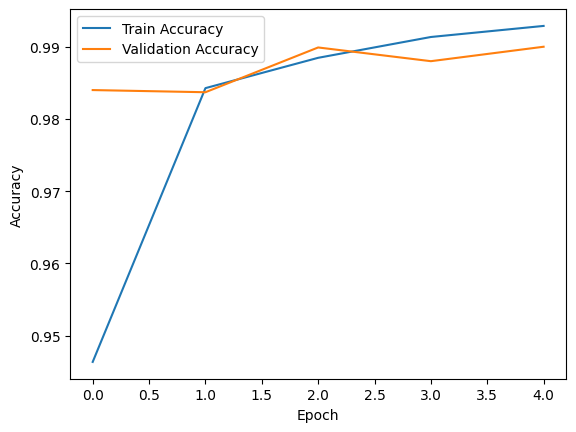

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


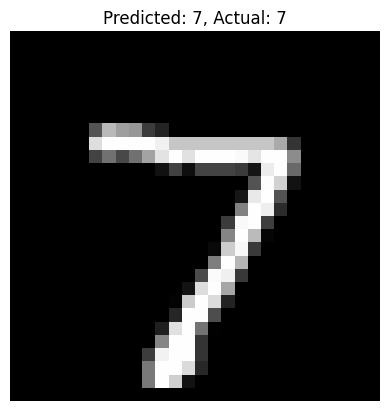

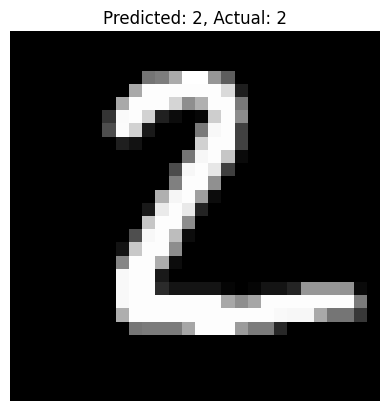

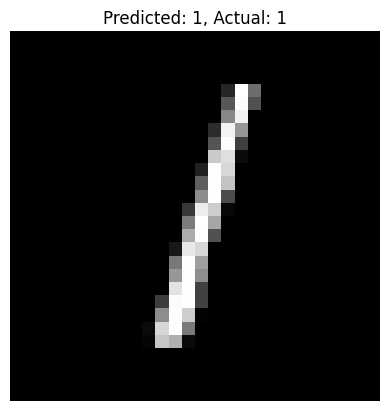

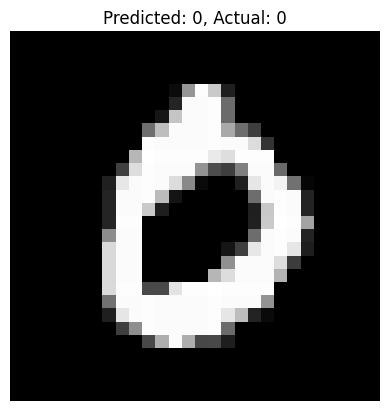

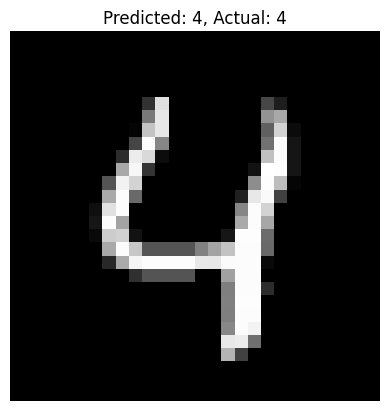

In [7]:
# MNIST Handwritten Digit Classification in Jupyter Notebook
# Works with TensorFlow 2.x

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape for CNN: (samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 2. Build a simple CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes for digits 0-9
])

# 3. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the model
history = model.fit(x_train, y_train, epochs=5, batch_size=64,
                    validation_data=(x_test, y_test))

# 5. Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

# 6. Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 7. Predict on first 5 test images
predictions = model.predict(x_test[:5])
for i in range(5):
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predictions[i].argmax()}, Actual: {y_test[i]}")
    plt.axis('off')
    plt.show()
